# Fraud Detection Modeling

## 1. Giriş (Introduction)

Bu çalışma kapsamında, dolandırıcılık (fraud) tespiti problemi için denetimli öğrenme yöntemleri kullanılarak sınıflandırma modelleri geliştirilmiştir. Veri setindeki sınıf dengesizliği göz önünde bulundurularak, modellerin performansını artırmak amacıyla ağırlıklandırma teknikleri uygulanmıştır.

LOGISTIC REGRESSION

In [1]:
# Veri işleme
import pandas as pd
import numpy as np

# Model bölme
from sklearn.model_selection import train_test_split

# Logistic Regression
from sklearn.linear_model import LogisticRegression

# Performans metrikleri
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Grafikler
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Feature-engineered dataset yükleniyor
df = pd.read_parquet("transaction_features_mvp_sample.parquet")

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (279972, 40)


,amount,log_amount,amount_zscore,high_amount,amount_to_limit_ratio,hour,day,month,year,day_of_week,...,user_mean_amount,user_std_amount,amount_deviation,time_diff,fast_tx,very_fast_tx,rolling_mean_3,rolling_std_3,rolling_amount_deviation,is_fraud
0,38.44,3.674781,-0.194635,0,0.001544,12,7,12,2018,Friday,...,62.180368,97.043952,-23.740368,2100.0,0,0,18.020000,18.723109,20.420000,0
1,4.71,1.742219,-0.641699,0,0.000293,11,22,7,2012,Sunday,...,29.201489,67.938937,-24.491489,18060.0,0,0,24.746667,32.335309,-20.036667,0
2,34.77,3.577110,-0.243278,0,0.001610,12,9,12,2017,Saturday,...,55.730116,59.643552,-20.960116,13020.0,0,0,48.306667,12.104596,-13.536667,0
3,57.00,4.060443,0.051363,0,0.002738,9,15,6,2014,Sunday,...,42.804189,47.763781,14.195811,540.0,0,0,42.226667,25.588164,14.773333,0
4,54.00,4.007333,0.011601,0,0.003971,7,27,7,2011,Wednesday,...,77.823015,104.888382,-23.823015,420.0,0,0,59.016667,8.689122,-5.016667,0


In [4]:
# Fraud kayıtlarını tamamen koruyoruz
fraud_df = df[df["is_fraud"] == 1].copy()

# Normal kayıtları ayırıyoruz
nonfraud_df = df[df["is_fraud"] == 0].copy()

print("Fraud satır sayısı:", len(fraud_df))
print("Non-fraud satır sayısı:", len(nonfraud_df))

# Yaklaşık 1:5 oranında non-fraud seçiyoruz
desired_nonfraud = min(len(nonfraud_df), len(fraud_df) * 5)

nonfraud_sample = nonfraud_df.sample(
    n=desired_nonfraud,
    random_state=42
)

# Birleştiriyoruz
df = pd.concat([fraud_df, nonfraud_sample], axis=0)

# Karıştırıyoruz
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Yeni dataset shape:", df.shape)
print(df["is_fraud"].value_counts())
print(df["is_fraud"].value_counts(normalize=True))

Fraud satır sayısı: 13332
Non-fraud satır sayısı: 266640
Yeni dataset shape: (79992, 40)
is_fraud
0    66660
1    13332
Name: count, dtype: int64
is_fraud
0    0.833333
1    0.166667
Name: proportion, dtype: float64


In [8]:
# Hedef değişken
y = df["is_fraud"]

# Modele girmemesi gereken ID kolonları çıkarılıyor
drop_cols = ["is_fraud", "transaction_id", "client_id", "card_id"]

drop_cols = [col for col in drop_cols if col in df.columns]

X = df.drop(columns=drop_cols)

print("Feature matrix shape:", X.shape)

Feature matrix shape: (79992, 39)


In [9]:
# Logistic Regression datetime ile çalışamaz

datetime_cols = X.select_dtypes(include=["datetime64[ns]"]).columns

X = X.drop(columns=datetime_cols, errors="ignore")

print("Datetime sonrası shape:", X.shape)

Datetime sonrası shape: (79992, 39)


In [10]:
# Kategorik değişkenleri sayısala çeviriyoruz

X = pd.get_dummies(X, drop_first=True)

print("Encoded feature matrix shape:", X.shape)

Encoded feature matrix shape: (79992, 4686)


In [ ]:
# RAM kullanımını azaltmak için float32 kullanıyoruz

#X = X.astype("float32")#

In [11]:
# Train-test split
# stratify=y fraud oranını korur

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (63993, 4686)
Test shape: (15999, 4686)


In [12]:
# Logistic Regression baseline modeli (class_weight olmadan)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

lr_baseline = LogisticRegression(
    max_iter=500,
    solver="liblinear"
)

# Modeli eğitiyoruz
lr_baseline.fit(X_train, y_train)

# Test verisi üzerinde tahmin yapıyoruz
y_pred_lr_base = lr_baseline.predict(X_test)
y_prob_lr_base = lr_baseline.predict_proba(X_test)[:, 1]

# Sonuçları yazdırıyoruz
print("Classification Report:\n")
print(classification_report(y_test, y_pred_lr_base))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_lr_base))

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_lr_base))

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.99      0.92     13333
           1       0.74      0.20      0.31      2666

    accuracy                           0.85     15999
   macro avg       0.80      0.59      0.61     15999
weighted avg       0.84      0.85      0.82     15999

Confusion Matrix:

[[13153   180]
 [ 2144   522]]
ROC-AUC Score: 0.8235967151992003


LOGISTIC REGRESSION + CLASS_WEIGHT

In [13]:
# Logistic Regression modeli (class_weight='balanced' ile)

lr_balanced = LogisticRegression(
    max_iter=500,
    solver="liblinear",
    class_weight="balanced"
)

# Modeli eğitiyoruz
lr_balanced.fit(X_train, y_train)

# Test verisi üzerinde tahmin yapıyoruz
y_pred_lr_bal = lr_balanced.predict(X_test)
y_prob_lr_bal = lr_balanced.predict_proba(X_test)[:, 1]

# Sonuçları yazdırıyoruz
print("Classification Report:\n")
print(classification_report(y_test, y_pred_lr_bal))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_lr_bal))

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_lr_bal))

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.95      0.97     13333
           1       0.80      0.93      0.86      2666

    accuracy                           0.95     15999
   macro avg       0.89      0.94      0.91     15999
weighted avg       0.95      0.95      0.95     15999

Confusion Matrix:

[[12698   635]
 [  189  2477]]
ROC-AUC Score: 0.9793087381573136


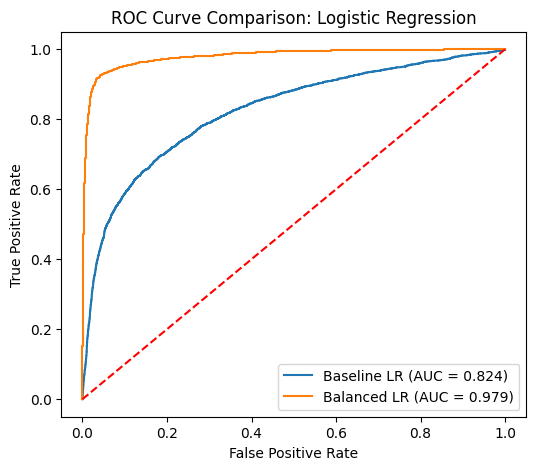

In [14]:
# ROC Curve karşılaştırması (Baseline vs Class_weight Logistic Regression)

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# ROC eğrisi için gerekli değerleri hesaplıyoruz
fpr_base, tpr_base, _ = roc_curve(y_test, y_prob_lr_base)
fpr_bal, tpr_bal, _ = roc_curve(y_test, y_prob_lr_bal)

# AUC skorlarını hesaplıyoruz
auc_base = roc_auc_score(y_test, y_prob_lr_base)
auc_bal = roc_auc_score(y_test, y_prob_lr_bal)

# Grafiği çiziyoruz
plt.figure(figsize=(6,5))

plt.plot(fpr_base, tpr_base, label=f"Baseline LR (AUC = {auc_base:.3f})")
plt.plot(fpr_bal, tpr_bal, label=f"Balanced LR (AUC = {auc_bal:.3f})")

# Referans çizgisi (rastgele model)
plt.plot([0,1], [0,1], 'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison: Logistic Regression")

plt.legend()
plt.show()

Class imbalance problemi nedeniyle baseline Logistic Regression modeli fraud işlemleri yakalamakta yetersiz kalmıştır (recall = 0.20). Class_weight parametresi eklendikten sonra modelin fraud sınıfını yakalama başarısı önemli ölçüde artmış (recall = 0.93) ve ROC-AUC skoru 0.82’den 0.97’ye yükselmiştir. Bu sonuçlar sınıf dengesizliği probleminin ağırlıklandırma yöntemi ile etkili şekilde azaltılabildiğini göstermektedir.

XGBOOST

In [16]:
# XGBoost baseline modeli

from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Model oluşturuyoruz
xgb_baseline = XGBClassifier(
    n_estimators=100,      # ağaç sayısı
    max_depth=6,           # ağaç derinliği
    learning_rate=0.1,     # öğrenme hızı
    random_state=42,
    eval_metric="logloss"
)

# Modeli eğitiyoruz
xgb_baseline.fit(X_train, y_train)

# Tahmin alıyoruz
y_pred_xgb_base = xgb_baseline.predict(X_test)
y_prob_xgb_base = xgb_baseline.predict_proba(X_test)[:, 1]

# Sonuçları yazdırıyoruz
print("Classification Report:\n")
print(classification_report(y_test, y_pred_xgb_base))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_xgb_base))

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_xgb_base))

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.99      0.99     13333
           1       0.95      0.92      0.94      2666

    accuracy                           0.98     15999
   macro avg       0.97      0.96      0.96     15999
weighted avg       0.98      0.98      0.98     15999

Confusion Matrix:

[[13194   139]
 [  203  2463]]
ROC-AUC Score: 0.9948542130657542


XGBoost baseline modeli Logistic Regression modeline kıyasla daha yüksek ROC-AUC (0.994) ve precision değerleri elde etmiştir. Model fraud işlemlerin %92’sini doğru şekilde tespit edebilmiştir. Bu sonuçlar XGBoost algoritmasının fraud detection probleminde daha güçlü bir sınıflandırma performansı sunduğunu göstermektedir.

XGBoost + scale_pos_weight

In [17]:
# XGBoost için class imbalance oranını hesaplıyoruz
# negatif sınıf / pozitif sınıf

scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 4.999718732420776


In [18]:
# XGBoost modeli (scale_pos_weight ile)

from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

xgb_weighted = XGBClassifier(
    n_estimators=100,       # ağaç sayısı
    max_depth=6,            # ağaç derinliği
    learning_rate=0.1,      # öğrenme hızı
    scale_pos_weight=scale_pos_weight,   # fraud sınıfına daha fazla ağırlık
    random_state=42,
    eval_metric="logloss"
)

# Modeli eğitiyoruz
xgb_weighted.fit(X_train, y_train)

# Tahmin alıyoruz
y_pred_xgb_weighted = xgb_weighted.predict(X_test)
y_prob_xgb_weighted = xgb_weighted.predict_proba(X_test)[:, 1]

# Sonuçları yazdırıyoruz
print("Classification Report:\n")
print(classification_report(y_test, y_pred_xgb_weighted))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_xgb_weighted))

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_xgb_weighted))

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.98      0.98     13333
           1       0.89      0.96      0.92      2666

    accuracy                           0.97     15999
   macro avg       0.94      0.97      0.95     15999
weighted avg       0.97      0.97      0.97     15999

Confusion Matrix:

[[13029   304]
 [  116  2550]]
ROC-AUC Score: 0.9953512622511737


XGBoost modeline scale_pos_weight parametresi eklenerek azınlık sınıfı olan fraud işlemlerine daha fazla ağırlık verilmiştir. Bu sayede fraud işlemleri yakalama başarısı %92’den %96’ya yükselmiştir. ROC-AUC skorunun da 0.995 seviyesine çıkması modelin sınıfları ayırt etme performansının arttığını göstermektedir.

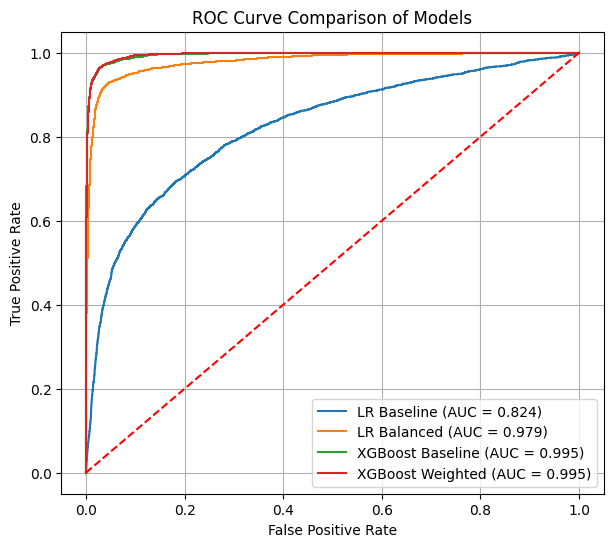

In [19]:
# ROC Curve karşılaştırması (tüm modeller)

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

# Logistic Regression baseline
fpr_lr_base, tpr_lr_base, _ = roc_curve(y_test, y_prob_lr_base)
auc_lr_base = roc_auc_score(y_test, y_prob_lr_base)
plt.plot(fpr_lr_base, tpr_lr_base, label=f"LR Baseline (AUC = {auc_lr_base:.3f})")

# Logistic Regression + class_weight
fpr_lr_bal, tpr_lr_bal, _ = roc_curve(y_test, y_prob_lr_bal)
auc_lr_bal = roc_auc_score(y_test, y_prob_lr_bal)
plt.plot(fpr_lr_bal, tpr_lr_bal, label=f"LR Balanced (AUC = {auc_lr_bal:.3f})")

# XGBoost baseline
fpr_xgb_base, tpr_xgb_base, _ = roc_curve(y_test, y_prob_xgb_base)
auc_xgb_base = roc_auc_score(y_test, y_prob_xgb_base)
plt.plot(fpr_xgb_base, tpr_xgb_base, label=f"XGBoost Baseline (AUC = {auc_xgb_base:.3f})")

# XGBoost + scale_pos_weight
fpr_xgb_weighted, tpr_xgb_weighted, _ = roc_curve(y_test, y_prob_xgb_weighted)
auc_xgb_weighted = roc_auc_score(y_test, y_prob_xgb_weighted)
plt.plot(fpr_xgb_weighted, tpr_xgb_weighted, label=f"XGBoost Weighted (AUC = {auc_xgb_weighted:.3f})")

# Rastgele model referans çizgisi
plt.plot([0,1], [0,1], "r--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Models")
plt.legend()
plt.grid(True)

plt.show()

<Figure size 1000x700 with 0 Axes>

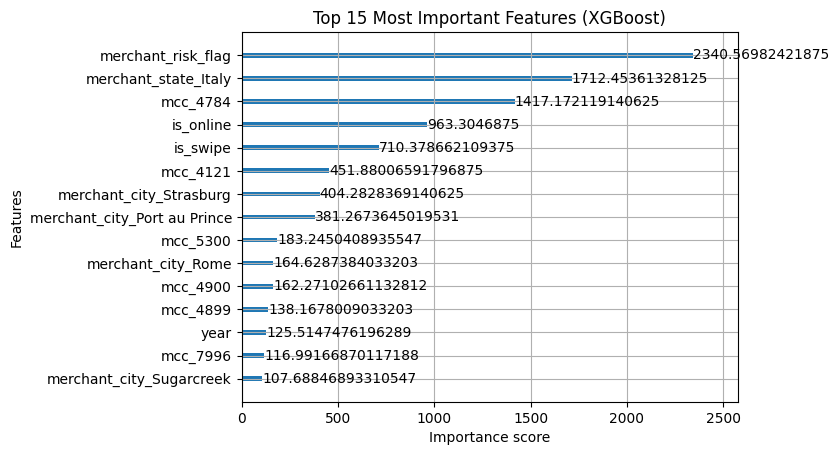

In [20]:
# XGBoost Feature Importance grafiği

from xgboost import plot_importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))

# Weighted XGBoost modelini kullanıyoruz (en iyi model)
plot_importance(
    xgb_weighted,
    max_num_features=15,   # en önemli 15 feature
    importance_type="gain" # model kararına katkı gücü
)

plt.title("Top 15 Most Important Features (XGBoost)")
plt.show()

Feature importance analizi sonucunda modelin özellikle merchant risk seviyesi, işlemin gerçekleştiği ülke, merchant kategori kodu (MCC) ve işlemin online olup olmaması gibi değişkenleri fraud tespitinde belirleyici olarak kullandığı gözlemlenmiştir. Bu sonuçlar modelin hem işlem davranışı hem de merchant özelliklerini birlikte değerlendirerek sınıflandırma yaptığını göstermektedir.

In [ ]:
import joblib

joblib.dump(xgb_weighted, "../models/fraud_model_final_merve.joblib")

['../models/fraud_model_final.joblib']